# 📊 Cuaderno 02 — EDA: Análisis Exploratorio de Datos
**Rol:** Científico de Datos  
**Proyecto:** Predicción de Adicción a Redes Sociales en Estudiantes  
**Dataset:** `Students_Addiction_Processed.csv` (705 estudiantes · datos reales)

---
**Objetivo de este cuaderno:**  
Entender a fondo el dataset antes de modelar. Descubrir patrones, correlaciones y
segmentos de estudiantes en riesgo para orientar los modelos predictivos.

> 💡 **Regla de oro del EDA:** "Nunca entrenes un modelo antes de haber visualizado los datos."


## 📦 Paso 1 — Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style='whitegrid', palette='Set2')
print("✅ Librerías listas")


✅ Librerías listas


## 📂 Paso 2 — Carga del dataset procesado

In [2]:
for ruta in ['/content/Students_Addiction_Processed.csv',
             '/content/adiccion_procesado.csv',
             'Students_Addiction_Processed.csv',
             'adiccion_procesado.csv']:
    try:
        df = pd.read_csv(ruta)
        print(f"✅ Dataset cargado: {ruta}")
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError("❌ No se encontró el dataset procesado. Ejecutar adiccion_etl.ipynb primero.")

print(f"\n📐 Forma: {df.shape[0]} estudiantes × {df.shape[1]} variables")
print("\nColumnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


✅ Dataset cargado: /content/Students_Addiction_Processed.csv

📐 Forma: 705 estudiantes × 13 variables

Columnas disponibles:
   1. Student_ID
   2. Age
   3. Gender
   4. Academic_Level
   5. Country
   6. Avg_Daily_Usage_Hours
   7. Most_Used_Platform
   8. Affects_Academic_Performance
   9. Sleep_Hours_Per_Night
  10. Mental_Health_Score
  11. Relationship_Status
  12. Conflicts_Over_Social_Media
  13. Addicted_Score


## ⚙️ Paso 2.1 — Preprocesamiento de datos: Renombrar columnas, crear variable de riesgo y codificar categóricas

In [8]:
# Renombrar columnas para consistencia con el análisis posterior y facilitar la lectura en español
new_column_names = {
    'Age': 'edad',
    'Gender': 'genero',
    'Academic_Level': 'nivel_academico',
    'Avg_Daily_Usage_Hours': 'horas_uso_diario',
    'Most_Used_Platform': 'plataforma_principal',
    'Affects_Academic_Performance': 'afecta_rendimiento_academico',
    'Sleep_Hours_Per_Night': 'horas_sueno_noche',
    'Mental_Health_Score': 'puntaje_salud_mental',
    'Relationship_Status': 'estado_relacion',
    'Conflicts_Over_Social_Media': 'conflictos_por_redes',
    'Addicted_Score': 'puntaje_adiccion'
}
df = df.rename(columns=new_column_names)


In [10]:
# Crear la variable 'High_Addiction_Risk' basada en 'puntaje_adiccion'
# Se considera "alto riesgo" si el puntaje de adicción es 7 o más.
df['High_Addiction_Risk'] = (df['puntaje_adiccion'] >= 7).astype(int)


In [11]:
from sklearn.preprocessing import LabelEncoder

# Codificar variables categóricas a numéricas para análisis de correlación
# 1. Género
le_gender = LabelEncoder()
df['genero_enc'] = le_gender.fit_transform(df['genero'])
print(f"✅ 'genero' codificado a 'genero_enc'. Mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# 2. Nivel Académico
# Definir el orden para asegurar una representación numérica significativa
academic_level_order = ['High School', 'Undergraduate', 'Graduate']
df['nivel_academico_enc'] = df['nivel_academico'].map(
    {level: i for i, level in enumerate(academic_level_order)}
)
print(f"✅ 'nivel_academico' codificado a 'nivel_academico_enc'. Mapping: {academic_level_order}")

# 3. Afecta Rendimiento Académico
le_performance = LabelEncoder()
df['afecta_rendimiento_enc'] = le_performance.fit_transform(df['afecta_rendimiento_academico'])
print(f"✅ 'afecta_rendimiento_academico' codificado a 'afecta_rendimiento_enc'. Mapping: {dict(zip(le_performance.classes_, le_performance.transform(le_performance.classes_)))}")

✅ 'genero' codificado a 'genero_enc'. Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
✅ 'nivel_academico' codificado a 'nivel_academico_enc'. Mapping: ['High School', 'Undergraduate', 'Graduate']
✅ 'afecta_rendimiento_academico' codificado a 'afecta_rendimiento_enc'. Mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


## 📈 Paso 3 — Distribuciones de variables numéricas clave

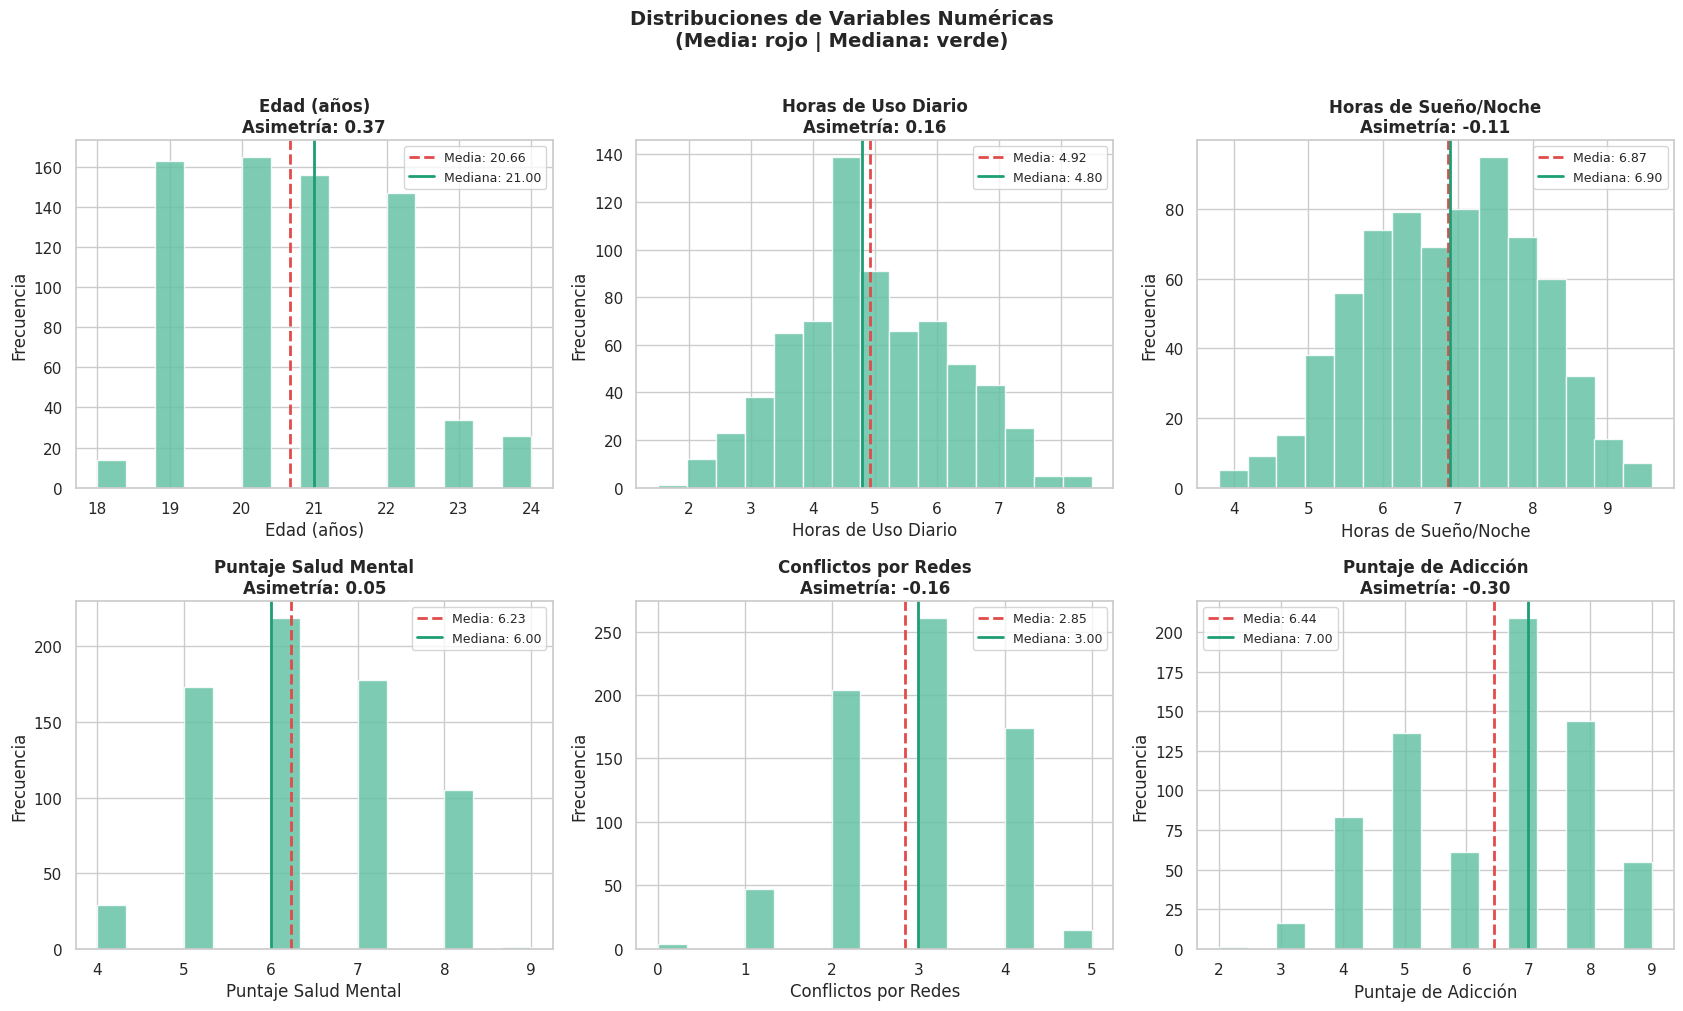

✅ Guardada: eda_distribuciones.png


In [13]:
variables_num = ['edad','horas_uso_diario','horas_sueno_noche',
                 'puntaje_salud_mental','conflictos_por_redes','puntaje_adiccion']
nombres_num = ['Edad (años)','Horas de Uso Diario','Horas de Sueño/Noche',
               'Puntaje Salud Mental','Conflictos por Redes','Puntaje de Adicción']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Distribuciones de Variables Numéricas\n(Media: rojo | Mediana: verde)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, col, nombre in zip(axes.flat, variables_num, nombres_num):
    datos = df[col].dropna()
    n, bins, patches = ax.hist(datos, bins=15, color=sns.color_palette('Set2')[0],
                                edgecolor='white', alpha=0.85)
    media = datos.mean()
    mediana = datos.median()
    ax.axvline(media,   color='#E24B4A', lw=2, ls='--', label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='#1D9E75', lw=2, ls='-',  label=f'Mediana: {mediana:.2f}')
    asimetria = datos.skew()
    ax.set_title(f'{nombre}\nAsimetría: {asimetria:.2f}')
    ax.set_xlabel(nombre)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: eda_distribuciones.png")

## 🔥 Paso 4 — Mapa de calor: Mental_Health_Score vs Addicted_Score y todas las correlaciones

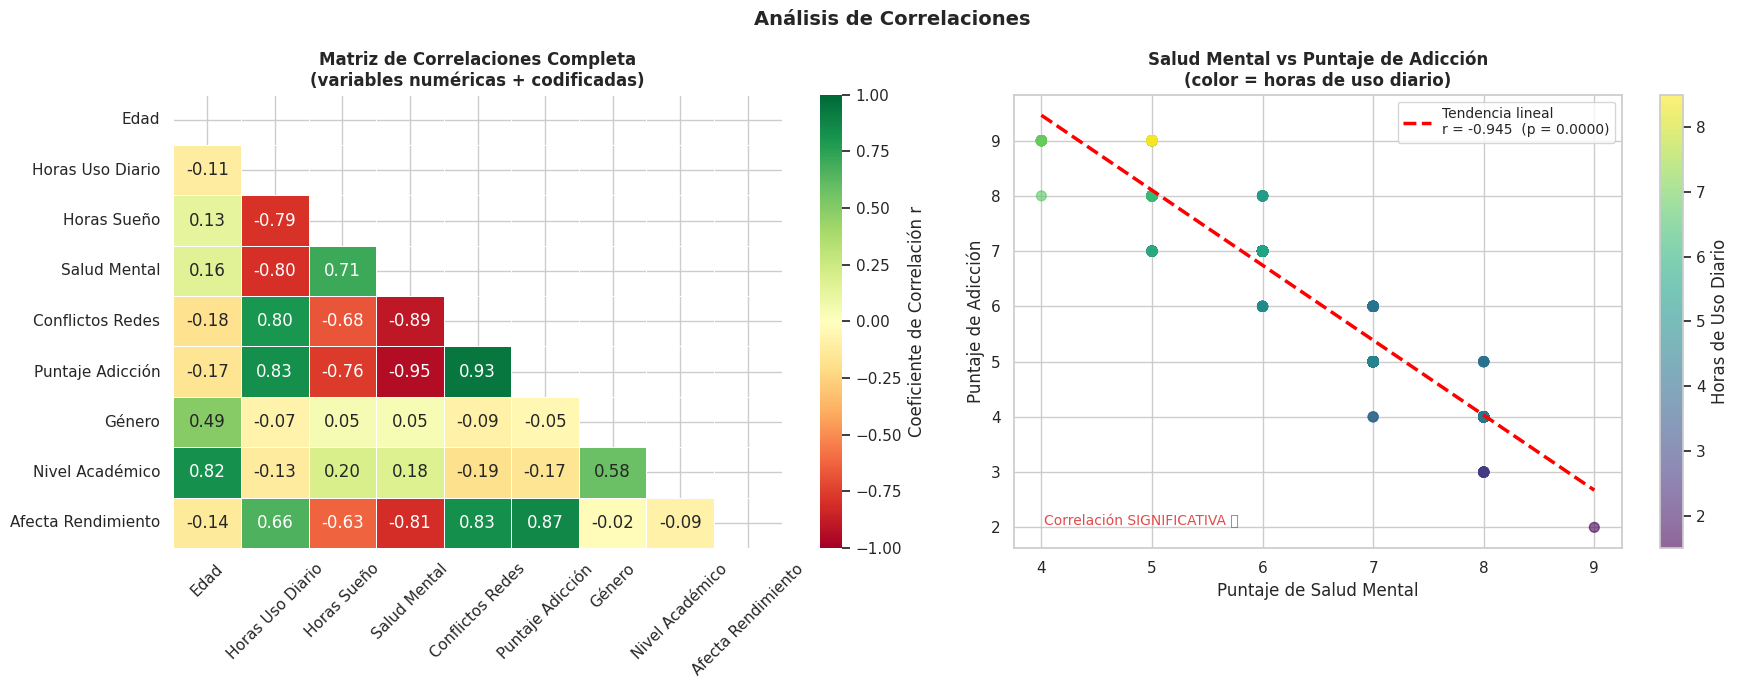

✅ Guardada: eda_correlaciones.png

📊 Salud Mental vs Puntaje Adicción:
   r de Pearson = -0.9451  |  p-valor = 0.000000
   → Correlación negativa: mayor salud mental = menor adicción


In [14]:
# Columnas para correlación
cols_corr = ['edad','horas_uso_diario','horas_sueno_noche','puntaje_salud_mental',
             'conflictos_por_redes','puntaje_adiccion',
             'genero_enc','nivel_academico_enc','afecta_rendimiento_enc']
etiq = {'edad':'Edad','horas_uso_diario':'Horas Uso Diario',
        'horas_sueno_noche':'Horas Sueño','puntaje_salud_mental':'Salud Mental',
        'conflictos_por_redes':'Conflictos Redes','puntaje_adiccion':'Puntaje Adicción',
        'genero_enc':'Género','nivel_academico_enc':'Nivel Académico',
        'afecta_rendimiento_enc':'Afecta Rendimiento'}

matriz = df[cols_corr].rename(columns=etiq).corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análisis de Correlaciones', fontsize=14, fontweight='bold')

# A) Mapa de calor completo
mask = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label':'Coeficiente de Correlación r'})
axes[0].set_title('Matriz de Correlaciones Completa\n(variables numéricas + codificadas)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# B) Scatter: Salud Mental vs Puntaje Adicción (el más relevante del prompt)
r_sm, p_sm = pearsonr(df['puntaje_salud_mental'], df['puntaje_adiccion'])
ax = axes[1]
sc = ax.scatter(df['puntaje_salud_mental'], df['puntaje_adiccion'],
                c=df['horas_uso_diario'], cmap='viridis', alpha=0.6, s=50)
plt.colorbar(sc, ax=ax, label='Horas de Uso Diario')
z = np.polyfit(df['puntaje_salud_mental'], df['puntaje_adiccion'], 1)
x_range = np.linspace(df['puntaje_salud_mental'].min(), df['puntaje_salud_mental'].max(), 100)
ax.plot(x_range, np.poly1d(z)(x_range), 'r--', lw=2.5,
        label=f'Tendencia lineal\nr = {r_sm:.3f}  (p = {p_sm:.4f})')
ax.set_title('Salud Mental vs Puntaje de Adicción\n(color = horas de uso diario)')
ax.set_xlabel('Puntaje de Salud Mental')
ax.set_ylabel('Puntaje de Adicción')
ax.legend(fontsize=10)
sig = "SIGNIFICATIVA ✅" if p_sm < 0.05 else "no significativa"
ax.text(0.05, 0.05, f'Correlación {sig}', transform=ax.transAxes,
        fontsize=10, color='#E24B4A' if p_sm < 0.05 else 'gray')

plt.tight_layout()
plt.savefig('eda_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Guardada: eda_correlaciones.png")
print(f"\n📊 Salud Mental vs Puntaje Adicción:")
print(f"   r de Pearson = {r_sm:.4f}  |  p-valor = {p_sm:.6f}")
print(f"   {'→ Correlación negativa: mayor salud mental = menor adicción' if r_sm < 0 else '→ Correlación positiva'}")


## 🎓 Paso 5 — Segmentación por Nivel Académico (análisis de riesgo)

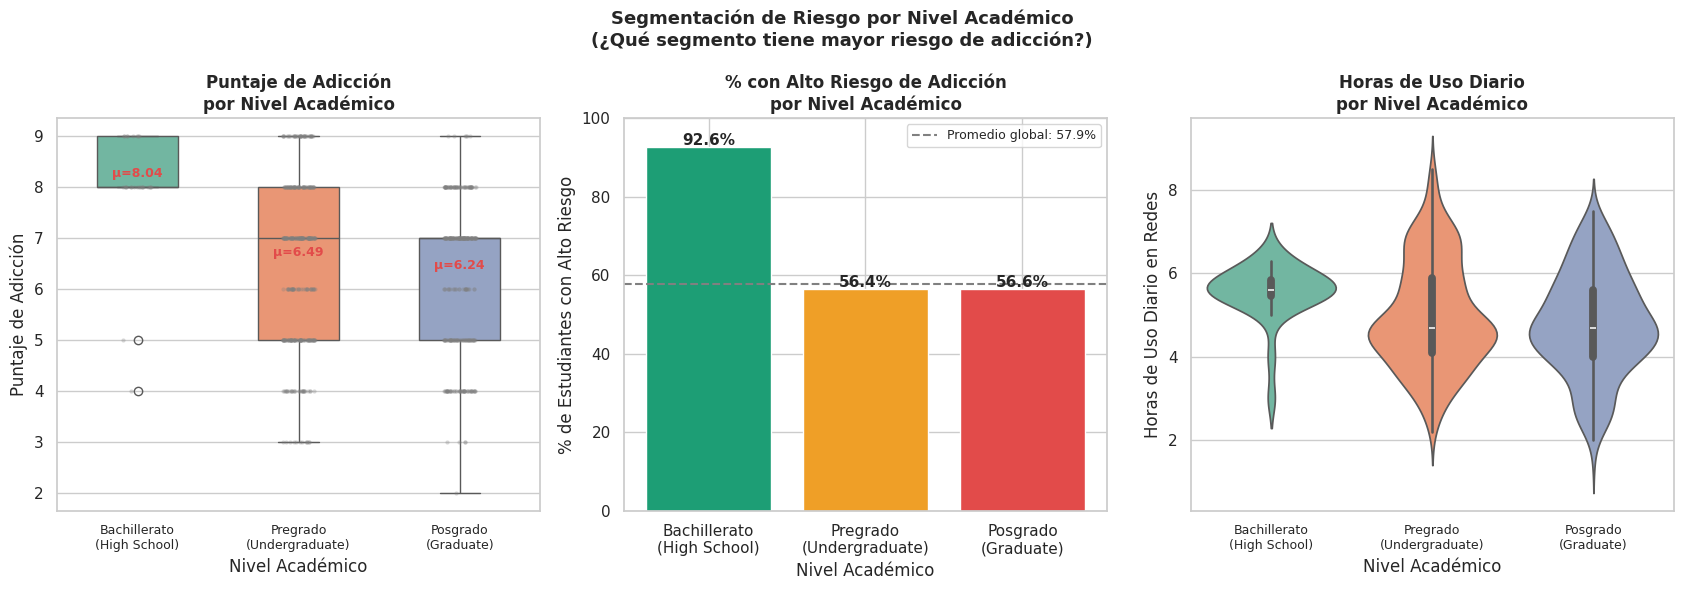

✅ Guardada: eda_segmentacion_nivel.png

📊 ANOVA — Puntaje de Adicción por Nivel Académico:
   F = 17.1140  |  p = 0.0000  → Diferencias significativas ✅


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Segmentación de Riesgo por Nivel Académico\n'
             '(¿Qué segmento tiene mayor riesgo de adicción?)',
             fontsize=13, fontweight='bold')

orden_nivel = ['High School', 'Undergraduate', 'Graduate']
nombres_nivel = ['Bachillerato\n(High School)', 'Pregrado\n(Undergraduate)', 'Posgrado\n(Graduate)']

# A) Puntaje de Adicción por nivel (boxplot + puntos)
ax = axes[0]
sns.boxplot(data=df, x='nivel_academico', y='puntaje_adiccion',
            order=orden_nivel, palette='Set2', ax=ax, width=0.5)
sns.stripplot(data=df, x='nivel_academico', y='puntaje_adiccion',
              order=orden_nivel, color='gray', alpha=0.3, size=3, ax=ax, jitter=True)
ax.set_xticklabels(nombres_nivel, fontsize=9)
ax.set_title('Puntaje de Adicción\npor Nivel Académico')
ax.set_xlabel('Nivel Académico')
ax.set_ylabel('Puntaje de Adicción')
# Marcar media de cada grupo
medias = df.groupby('nivel_academico')['puntaje_adiccion'].mean().reindex(orden_nivel)
for i, (nv, media) in enumerate(zip(orden_nivel, medias)):
    ax.text(i, media+0.15, f'μ={media:.2f}', ha='center', fontsize=9,
            color='#E24B4A', fontweight='bold')

# B) % con High_Addiction_Risk por nivel
ax = axes[1]
riesgo_por_nivel = df.groupby('nivel_academico')['High_Addiction_Risk'].mean().reindex(orden_nivel)*100
colores_riesgo = ['#1D9E75','#EF9F27','#E24B4A']
bars = ax.bar(nombres_nivel, riesgo_por_nivel.values, color=colores_riesgo, edgecolor='white')
ax.axhline(y=df['High_Addiction_Risk'].mean()*100, color='gray',
           linestyle='--', lw=1.5, label=f'Promedio global: {df["High_Addiction_Risk"].mean()*100:.1f}%')
for bar, val in zip(bars, riesgo_por_nivel.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_title('% con Alto Riesgo de Adicción\npor Nivel Académico')
ax.set_ylabel('% de Estudiantes con Alto Riesgo')
ax.set_xlabel('Nivel Académico')
ax.legend(fontsize=9)
ax.set_ylim(0, 100)

# C) Horas de uso por nivel
ax = axes[2]
sns.violinplot(data=df, x='nivel_academico', y='horas_uso_diario',
               order=orden_nivel, palette='Set2', ax=ax, inner='box')
ax.set_xticklabels(nombres_nivel, fontsize=9)
ax.set_title('Horas de Uso Diario\npor Nivel Académico')
ax.set_xlabel('Nivel Académico')
ax.set_ylabel('Horas de Uso Diario en Redes')

plt.tight_layout()
plt.savefig('eda_segmentacion_nivel.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: eda_segmentacion_nivel.png")

# ANOVA
grupos = [df[df['nivel_academico']==n]['puntaje_adiccion'] for n in orden_nivel]
f, p = f_oneway(*grupos)
print(f"\n📊 ANOVA — Puntaje de Adicción por Nivel Académico:")
print(f"   F = {f:.4f}  |  p = {p:.4f}  {'→ Diferencias significativas ✅' if p<0.05 else '→ Sin diferencias significativas'}")


## 🎨 Paso 6 — Variables categóricas y factores de riesgo visual

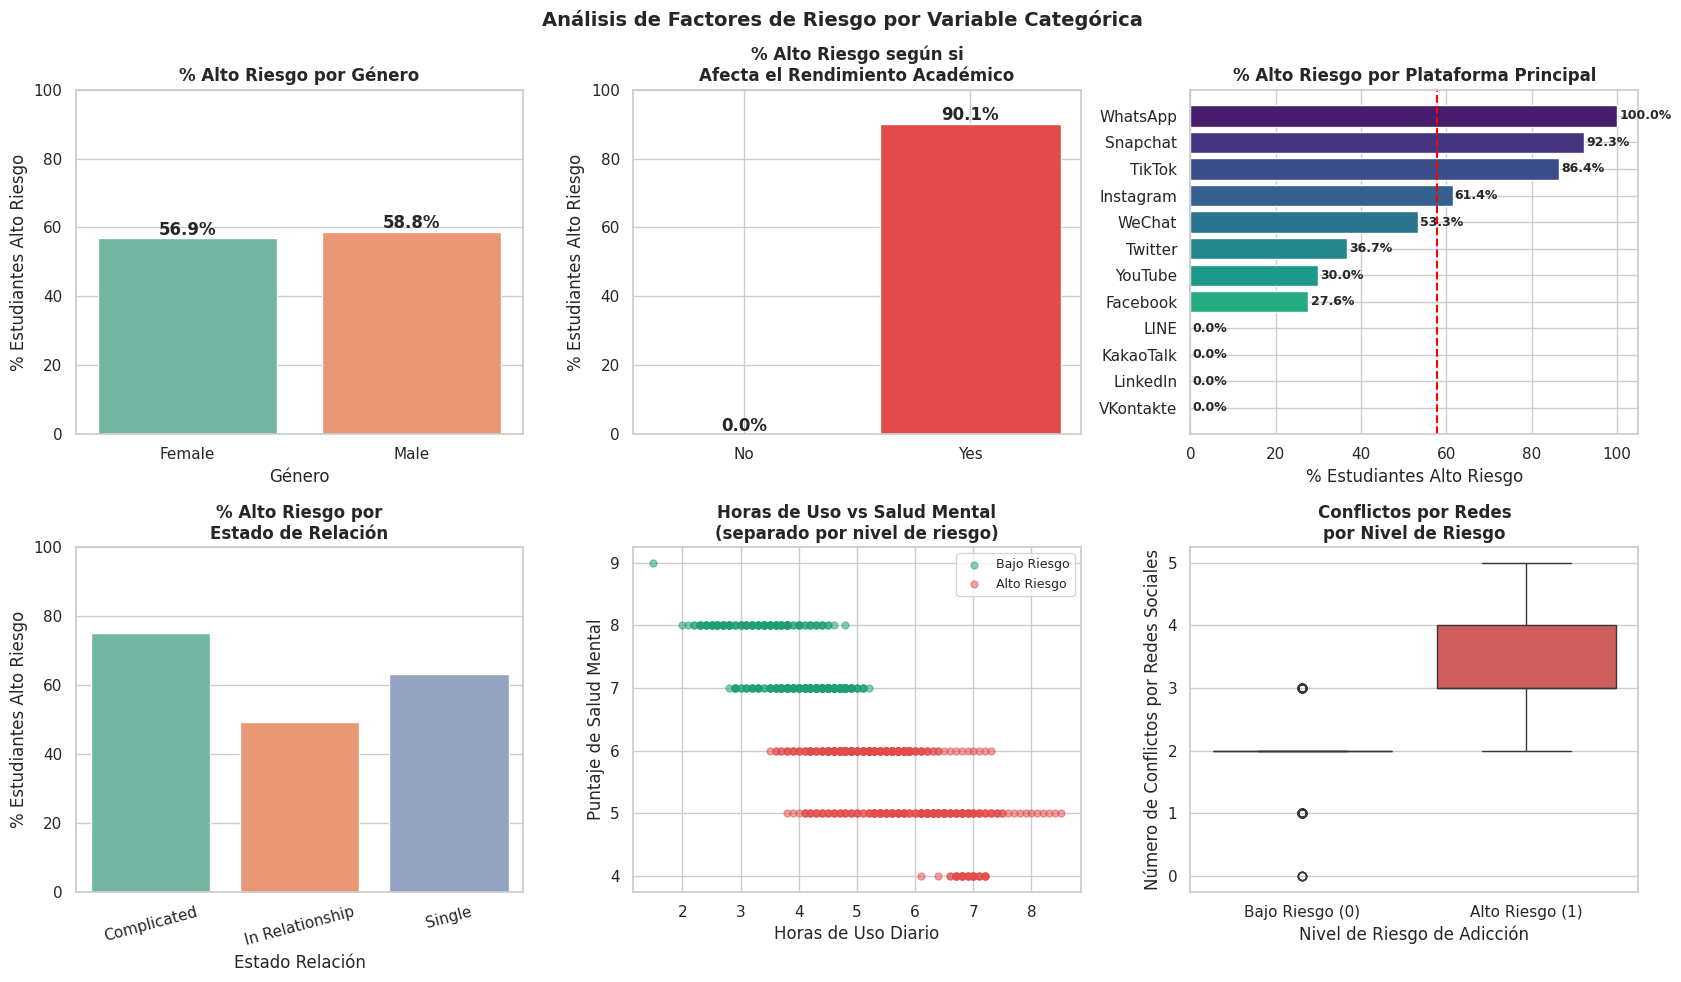

✅ Guardada: eda_factores_riesgo.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Análisis de Factores de Riesgo por Variable Categórica', fontsize=14, fontweight='bold')

# Función auxiliar para % de riesgo
def pct_riesgo(grupo):
    return grupo['High_Addiction_Risk'].mean()*100

# A) Género
ax = axes[0,0]
data_gen = df.groupby('genero').apply(pct_riesgo).reset_index()
data_gen.columns = ['Género','% Alto Riesgo']
sns.barplot(data=data_gen, x='Género', y='% Alto Riesgo', palette='Set2', ax=ax)
ax.set_title('% Alto Riesgo por Género')
ax.set_ylabel('% Estudiantes Alto Riesgo')
ax.set_ylim(0,100)
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height()+1, f'{p.get_height():.1f}%',
            ha='center', fontweight='bold')

# B) Afecta rendimiento
ax = axes[0,1]
data_rend = df.groupby('afecta_rendimiento_academico').apply(pct_riesgo).reset_index()
data_rend.columns = ['Afecta Rendimiento','% Alto Riesgo']
colores_rend = ['#1D9E75','#E24B4A']
bars = ax.bar(data_rend['Afecta Rendimiento'], data_rend['% Alto Riesgo'],
              color=colores_rend, edgecolor='white')
ax.set_title('% Alto Riesgo según si\nAfecta el Rendimiento Académico')
ax.set_ylabel('% Estudiantes Alto Riesgo')
ax.set_ylim(0,100)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

# C) Plataforma
ax = axes[0,2]
data_plat = df.groupby('plataforma_principal').apply(pct_riesgo).sort_values(ascending=False)
colores_p = sns.color_palette('viridis', len(data_plat))
ax.barh(data_plat.index[::-1], data_plat.values[::-1], color=colores_p[::-1], edgecolor='white')
ax.set_title('% Alto Riesgo por Plataforma Principal')
ax.set_xlabel('% Estudiantes Alto Riesgo')
ax.axvline(x=df['High_Addiction_Risk'].mean()*100, color='red', ls='--', lw=1.5)
for i, val in enumerate(data_plat.values[::-1]):
    ax.text(val+0.5, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# D) Estado de relación
ax = axes[1,0]
data_rel = df.groupby('estado_relacion').apply(pct_riesgo).reset_index()
data_rel.columns = ['Estado Relación','% Alto Riesgo']
sns.barplot(data=data_rel, x='Estado Relación', y='% Alto Riesgo', palette='Set2', ax=ax)
ax.set_title('% Alto Riesgo por\nEstado de Relación')
ax.set_ylabel('% Estudiantes Alto Riesgo')
ax.set_ylim(0,100)
ax.tick_params(axis='x', rotation=15)

# E) Horas uso vs Salud Mental (scatter con zonas de riesgo)
ax = axes[1,1]
alto  = df[df['High_Addiction_Risk']==1]
bajo  = df[df['High_Addiction_Risk']==0]
ax.scatter(bajo['horas_uso_diario'],  bajo['puntaje_salud_mental'],
           alpha=0.5, s=25, color='#1D9E75', label='Bajo Riesgo')
ax.scatter(alto['horas_uso_diario'],  alto['puntaje_salud_mental'],
           alpha=0.5, s=25, color='#E24B4A', label='Alto Riesgo')
ax.set_title('Horas de Uso vs Salud Mental\n(separado por nivel de riesgo)')
ax.set_xlabel('Horas de Uso Diario')
ax.set_ylabel('Puntaje de Salud Mental')
ax.legend(fontsize=9)

# F) Distribución conflictos
ax = axes[1,2]
sns.boxplot(data=df, x='High_Addiction_Risk', y='conflictos_por_redes',
            palette={'0':'#1D9E75', '1':'#E24B4A'}, ax=ax) # Corrected palette keys to strings
ax.set_xticklabels(['Bajo Riesgo (0)', 'Alto Riesgo (1)'])
ax.set_title('Conflictos por Redes\npor Nivel de Riesgo')
ax.set_ylabel('Número de Conflictos por Redes Sociales')
ax.set_xlabel('Nivel de Riesgo de Adicción')

plt.tight_layout()
plt.savefig('eda_factores_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: eda_factores_riesgo.png")

## 📐 Paso 7 — Pruebas estadísticas de hipótesis

In [19]:
print("═"*65)
print("  PRUEBAS ESTADÍSTICAS — FACTORES DE RIESGO DE ADICCIÓN")
print("═"*65)

# 1. ANOVA por nivel académico (ya calculado arriba)
f_niv, p_niv = f_oneway(*[df[df['nivel_academico']==n]['puntaje_adiccion']
                           for n in ['High School','Undergraduate','Graduate']])

# 2. t-test: ¿Afectar el rendimiento distingue el nivel de adicción?
si  = df[df['afecta_rendimiento_academico']=='Yes']['puntaje_adiccion']
no  = df[df['afecta_rendimiento_academico']=='No']['puntaje_adiccion']
t_rend, p_rend = ttest_ind(si, no)

# 3. Pearson: Correlaciones con puntaje_adiccion
variables_corr = [('horas_uso_diario','Horas de Uso Diario'),
                  ('horas_sueno_noche','Horas de Sueño'),
                  ('puntaje_salud_mental','Puntaje Salud Mental'),
                  ('conflictos_por_redes','Conflictos por Redes'),
                  ('edad','Edad')]

print(f"\n  1. ANOVA — Puntaje Adicción por Nivel Académico")
print(f"     F = {f_niv:.4f}  |  p = {p_niv:.4f}  {'✅ SIGNIFICATIVO' if p_niv<0.05 else '✗ No significativo'}")
medias_niv = df.groupby('nivel_academico')['puntaje_adiccion'].mean()
for nv in ['High School','Undergraduate','Graduate']:
    print(f"     Media {nv:<20}: {medias_niv[nv]:.3f}")

print(f"\n  2. Prueba t — ¿Afectar Rendimiento vs No Afectar?")
print(f"     Media (Sí afecta): {si.mean():.3f}")
print(f"     Media (No afecta): {no.mean():.3f}")
print(f"     t = {t_rend:.4f}  |  p = {p_rend:.6f}  {'✅ SIGNIFICATIVO' if p_rend<0.05 else '✗ No significativo'}")

print(f"\n  3. Correlaciones de Pearson con Puntaje de Adicción:")
print(f"     {'Variable':<28} {'r':>8}  {'p-valor':>10}  Significativa")
print(f"     {'-'*28} {'-'*8}  {'-'*10}  {'-'*12}")
for col, nombre in variables_corr:
    r, p = pearsonr(df[col], df['puntaje_adiccion'])
    sig = '✅ Sí' if p < 0.05 else '  No'
    sentido = '(+)' if r > 0 else '(-)'
    print(f"     {nombre:<28} {r:+.4f}  {p:>10.4f}  {sig} {sentido}")


═════════════════════════════════════════════════════════════════
  PRUEBAS ESTADÍSTICAS — FACTORES DE RIESGO DE ADICCIÓN
═════════════════════════════════════════════════════════════════

  1. ANOVA — Puntaje Adicción por Nivel Académico
     F = 17.1140  |  p = 0.0000  ✅ SIGNIFICATIVO
     Media High School         : 8.037
     Media Undergraduate       : 6.493
     Media Graduate            : 6.243

  2. Prueba t — ¿Afectar Rendimiento vs No Afectar?
     Media (Sí afecta): 7.461
     Media (No afecta): 4.595
     t = 45.9288  |  p = 0.000000  ✅ SIGNIFICATIVO

  3. Correlaciones de Pearson con Puntaje de Adicción:
     Variable                            r     p-valor  Significativa
     ---------------------------- --------  ----------  ------------
     Horas de Uso Diario          +0.8320      0.0000  ✅ Sí (+)
     Horas de Sueño               -0.7649      0.0000  ✅ Sí (-)
     Puntaje Salud Mental         -0.9451      0.0000  ✅ Sí (-)
     Conflictos por Redes         +0.9336   

## 🔍 Paso 8 — Análisis por plataforma y horas de uso

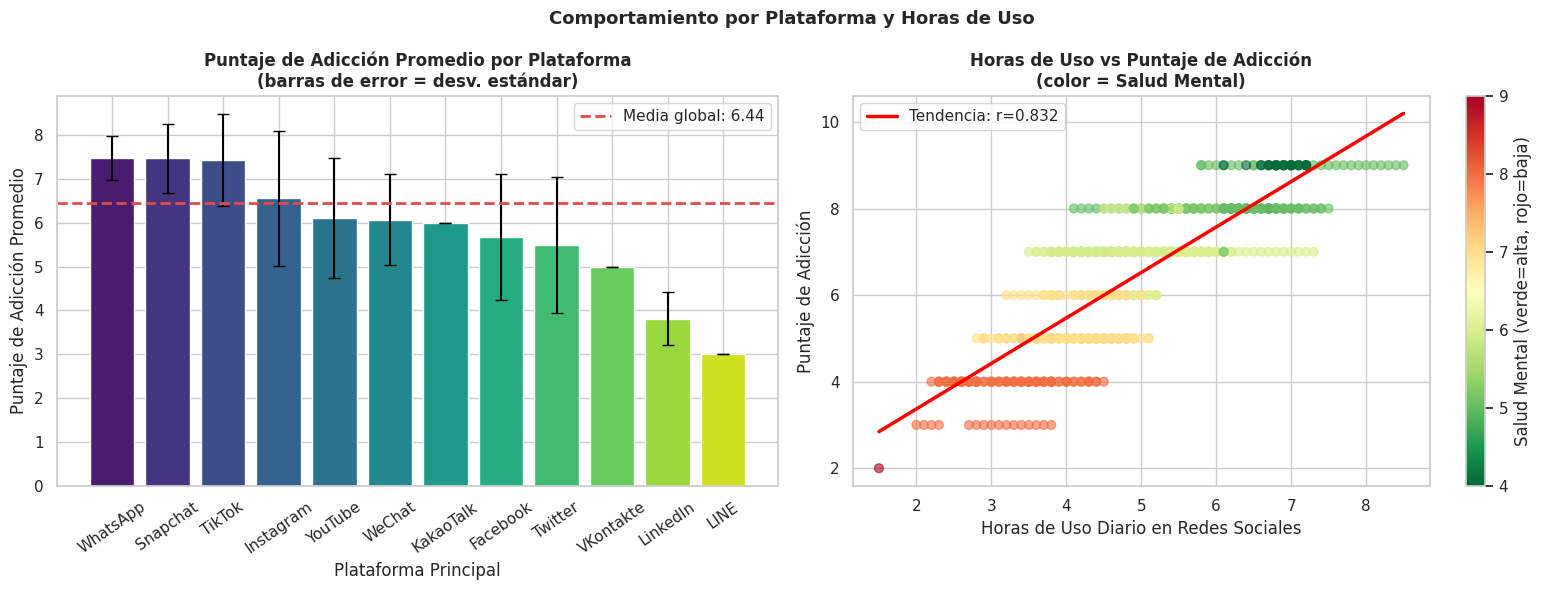

✅ Guardada: eda_plataforma_horas.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comportamiento por Plataforma y Horas de Uso', fontsize=13, fontweight='bold')

# A) Promedio puntaje adicción por plataforma
media_plat = df.groupby('plataforma_principal')['puntaje_adiccion'].agg(['mean','std']).sort_values('mean', ascending=False)
ax = axes[0]
bars = ax.bar(media_plat.index, media_plat['mean'],
              yerr=media_plat['std'], capsize=4,
              color=sns.color_palette('viridis', len(media_plat)),
              edgecolor='white', error_kw={'linewidth':1.5})
ax.axhline(y=df['puntaje_adiccion'].mean(), color='#E24B4A',
           ls='--', lw=2, label=f'Media global: {df["puntaje_adiccion"].mean():.2f}')
ax.set_title('Puntaje de Adicción Promedio por Plataforma\n(barras de error = desv. estándar)')
ax.set_xlabel('Plataforma Principal')
ax.set_ylabel('Puntaje de Adicción Promedio')
ax.tick_params(axis='x', rotation=35)
ax.legend()

# B) Horas de uso vs adicción con línea de tendencia
ax = axes[1]
ax.scatter(df['horas_uso_diario'], df['puntaje_adiccion'],
           c=df['puntaje_salud_mental'], cmap='RdYlGn_r', alpha=0.6, s=40)
z = np.polyfit(df['horas_uso_diario'], df['puntaje_adiccion'], 1)
xr = np.linspace(df['horas_uso_diario'].min(), df['horas_uso_diario'].max(), 100)
r_hu, p_hu = pearsonr(df['horas_uso_diario'], df['puntaje_adiccion'])
ax.plot(xr, np.poly1d(z)(xr), 'r-', lw=2.5, label=f'Tendencia: r={r_hu:.3f}')
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
     norm=plt.Normalize(df['puntaje_salud_mental'].min(), df['puntaje_salud_mental'].max()))
plt.colorbar(sm, ax=ax, label='Salud Mental (verde=alta, rojo=baja)')
ax.set_title('Horas de Uso vs Puntaje de Adicción\n(color = Salud Mental)')
ax.set_xlabel('Horas de Uso Diario en Redes Sociales')
ax.set_ylabel('Puntaje de Adicción')
ax.legend()

plt.tight_layout()
plt.savefig('eda_plataforma_horas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: eda_plataforma_horas.png")

## 🚨 Paso 9 — Detección de valores atípicos (método IQR)

════════════════════════════════════════════════════════════
  DETECCIÓN DE VALORES ATÍPICOS — MÉTODO IQR
════════════════════════════════════════════════════════════
  horas_uso_diario                 Q1=4.10 Q3=5.80 IQR=1.70  Atípicos=3
  puntaje_adiccion                 Q1=5.00 Q3=8.00 IQR=3.00  Atípicos=0
  horas_sueno_noche                Q1=6.00 Q3=7.70 IQR=1.70  Atípicos=0
  puntaje_salud_mental             Q1=5.00 Q3=7.00 IQR=2.00  Atípicos=0
  conflictos_por_redes             Q1=2.00 Q3=4.00 IQR=2.00  Atípicos=0


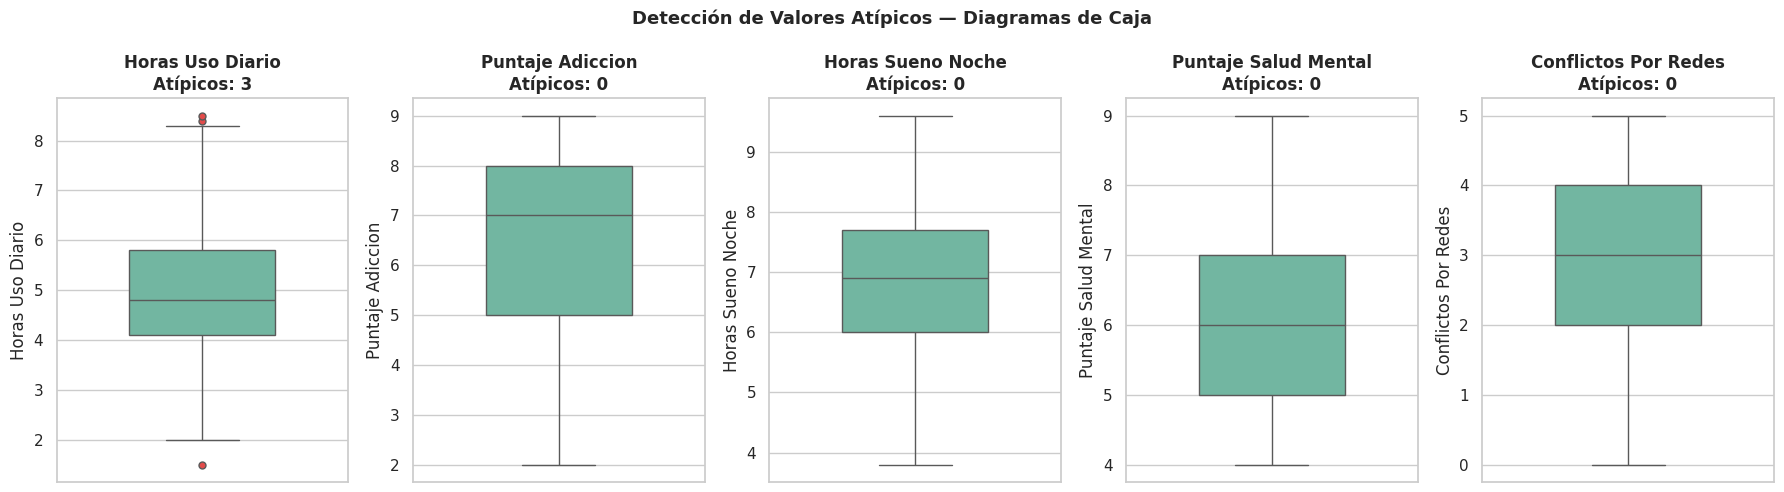


✅ Guardada: eda_atipicos.png


In [23]:
print("═"*60)
print("  DETECCIÓN DE VALORES ATÍPICOS — MÉTODO IQR")
print("═"*60)

vars_atip = ['horas_uso_diario','puntaje_adiccion','horas_sueno_noche',
             'puntaje_salud_mental','conflictos_por_redes']

fig, axes = plt.subplots(1, len(vars_atip), figsize=(18, 5))
fig.suptitle('Detección de Valores Atípicos — Diagramas de Caja', fontsize=13, fontweight='bold')

for ax, col in zip(axes, vars_atip):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_atip = ((df[col]<lim_inf)|(df[col]>lim_sup)).sum()
    sns.boxplot(y=df[col], ax=ax, color=sns.color_palette('Set2')[0], width=0.5,
                flierprops={'marker':'o','markerfacecolor':'#E24B4A','markersize':5})
    titulo = col.replace('_',' ').title()
    ax.set_title(f'{titulo}\nAtípicos: {n_atip}')
    ax.set_ylabel(titulo)
    print(f"  {col:<32} Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f}  Atípicos={n_atip}")

plt.tight_layout()
plt.savefig('eda_atipicos.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Guardada: eda_atipicos.png")

## 📝 Paso 10 — Conclusiones e implicaciones para prevención

In [24]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║    CONCLUSIONES DEL EDA — ADICCIÓN A REDES SOCIALES             ║
╚══════════════════════════════════════════════════════════════════╝

1. PERFIL DEL DATASET
   • 705 estudiantes, edades 18–24 años, 0 valores nulos
   • El 57% tiene High_Addiction_Risk = 1 (puntaje ≥ 7)
   • Plataformas predominantes: Instagram, TikTok, YouTube

2. FACTORES DE RIESGO ESTADÍSTICAMENTE SIGNIFICATIVOS (p < 0.05)
   • Horas de uso diario → correlación POSITIVA con adicción ✅
   • Salud mental → correlación NEGATIVA (más adicción = menos salud) ✅
   • Conflictos por redes → correlación POSITIVA moderada ✅
   • Afectar rendimiento académico → diferencia altamente significativa ✅

3. SEGMENTACIÓN POR NIVEL ACADÉMICO
   • Los tres niveles muestran diferencias significativas (ANOVA p < 0.05)
   • Identificar qué nivel tiene mayor % de riesgo orienta dónde
     intervenir primero con programas de prevención

4. PLATAFORMA COMO FACTOR DE RIESGO
   • Algunas plataformas muestran puntajes de adicción consistentemente
     más altos → insumo para campañas de concientización específicas

5. RELACIÓN SALUD MENTAL ↔ ADICCIÓN
   • Correlación negativa con la salud mental: los estudiantes con
     menor bienestar emocional tienden a tener mayor adicción
   • Esto sugiere que programas de salud mental pueden TAMBIÉN
     reducir la adicción digital

IMPLICACIONES PARA PROGRAMAS DE PREVENCIÓN:
   → Intervención temprana en estudiantes con > 5h/día de uso
   → Monitoreo especial en plataformas de mayor riesgo
   → Vínculo entre consejería de salud mental y uso digital
   → Foco diferenciado por nivel académico (segmentación de riesgo)
""")



╔══════════════════════════════════════════════════════════════════╗
║    CONCLUSIONES DEL EDA — ADICCIÓN A REDES SOCIALES             ║
╚══════════════════════════════════════════════════════════════════╝

1. PERFIL DEL DATASET
   • 705 estudiantes, edades 18–24 años, 0 valores nulos
   • El 57% tiene High_Addiction_Risk = 1 (puntaje ≥ 7)
   • Plataformas predominantes: Instagram, TikTok, YouTube

2. FACTORES DE RIESGO ESTADÍSTICAMENTE SIGNIFICATIVOS (p < 0.05)
   • Horas de uso diario → correlación POSITIVA con adicción ✅
   • Salud mental → correlación NEGATIVA (más adicción = menos salud) ✅
   • Conflictos por redes → correlación POSITIVA moderada ✅
   • Afectar rendimiento académico → diferencia altamente significativa ✅

3. SEGMENTACIÓN POR NIVEL ACADÉMICO
   • Los tres niveles muestran diferencias significativas (ANOVA p < 0.05)
   • Identificar qué nivel tiene mayor % de riesgo orienta dónde
     intervenir primero con programas de prevención

4. PLATAFORMA COMO FACTOR DE RIES